# Proyek System Recomendation - Supermarket Rekomendasi

- **Nama:** Nur Adilah
- **Email:** nuradilah@students.usu.ac.id
- **ID Dicoding:** MC319D5X0793 NUR ADILAH

Pertama install terlebih dahulu library implicit

In [1]:
!pip install implicit==0.7.0
print("Library 'implicit' berhasil diinstal.")

Library 'implicit' berhasil diinstal.


# Import Library

Mengimport beberapa ibrary yang di perlukan

In [2]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from scipy.sparse import coo_matrix
import implicit
from sklearn.metrics import mean_squared_error, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [3]:
# load dataset
supermarket = pd.read_csv('/content/supermarket_dataset.csv')

supermarket

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


**Insight:**

Terdat 1000 baris dalam dataset ini dan 17 kolom yaitu:

- 'InvoiceID': ID Transaksi, menunjukkan transaksi unik, akan digunakan untuk Collaborative Filtering.
- 'Branch' & 'City': Cabang toko yang masing-masing berada di kota yang berbeda.
- 'Customer type': Ada dua jenis pelanggan yaitu `Member` dan `Normal`.
- 'Gender': Jenis kelamin pelanggan antara laki-laki (`Male`) dan perempuan (`Female`).
- 'Product Line': Kategori produk yang dibeli, misalnya Health and beauty, Electronic accesories, Home and lifestyle, dll. Menunjukkan jenis produk yang dibeli, penting untuk Content-based Filtering.
- 'Unit Price': Harga satuan produk.
- 'Quantity': Jumlah item yang dibeli
- 'Total': Total transaksi (Unit price x Quantity).
- 'Date' & 'Time': waktu transaksi.
- 'Payment': Metode pembayaran, yang terdapat tiga metode digunakan: `Cash`, `Credit card`, dan `Ewallet`.
- 'Rating': Penilaian pelanggan terhadap transaksi. Dapat digunakan sebagai implicit feedback atau relevansi produk.

# Data Understanding

In [4]:
print("Data shape:", supermarket.shape)

Data shape: (1000, 17)


Kode tersebut memberikan informasi bahwa terdapa 1000 baris dan 17 kolom pada dataset

In [5]:
print("Data Info:")
supermarket.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin p

Kode tersebut bertujuan untuk menampilkan informasi umum dari dataset `supermarket`, seperti jumlah baris, kolom, tipe data tiap kolom, dan jumlah nilai non-null. Hal ini penting untuk memahami struktur data sebelum melakukan analisis lebih lanjut.

In [6]:
print("\nStatistik Deskriptif:")
supermarket.describe()


Statistik Deskriptif:


,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


Kode diatas digunakan untuk menampilkan ringkasan statistik deskriptif dari fitur numerik dalam dataset, seperti nilai mean, standar deviasi, nilai minimum dan maksimum, serta kuartil. Tujuannya adalah untuk mendapatkan gambaran awal mengenai distribusi data.

In [7]:
# Melihat Jumlah Nilai Unik pada Fitur Kategorikal
print("\nUnique Product Lines:", supermarket['Product line'].nunique())
print("Unique Customer Types:", supermarket['Customer type'].unique())


Unique Product Lines: 6
Unique Customer Types: ['Member' 'Normal']


Kode diatas digunakan untuk menghitung jumlah nilai unik pada beberapa kolom kategorikal penting, yaitu:
- `Product line`: jenis produk yang dijual,
- `Customer type`: jenis pelanggan

Informasi ini berguna untuk memahami keberagaman kategori dalam dataset.

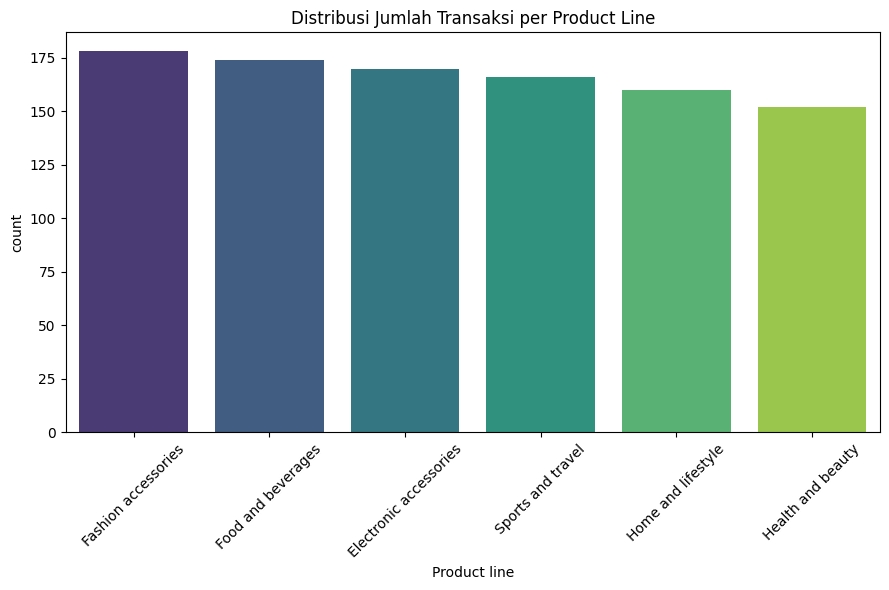

In [8]:
# Visualisasi distribusi Product line (produk terjual terbanyak)
plt.figure(figsize=(9, 6))
sns.countplot(data=supermarket, x='Product line', order=supermarket['Product line'].value_counts().index, palette='viridis')
plt.title('Distribusi Jumlah Transaksi per Product Line')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Visualisasi ini digunakan untuk melihat distribusi jumlah produk yang terjual berdasarkan kategori `Product line`.
Plot ini membantu mengidentifikasi kategori produk apa yang paling banyak atau paling sedikit dibeli oleh pelanggan.

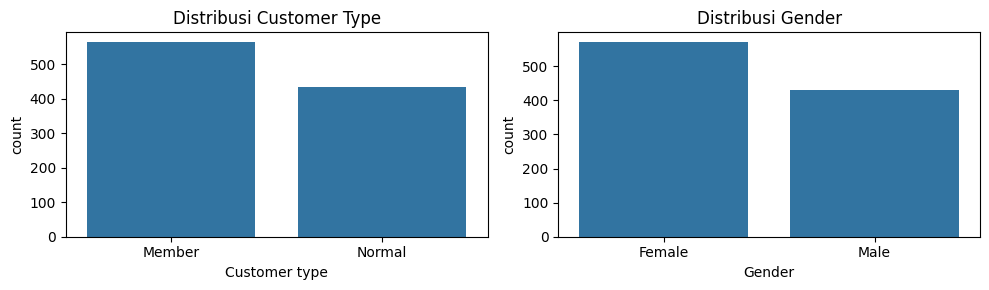

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Distribusi Customer Type
sns.countplot(data=supermarket, x='Customer type', ax=axes[0])
axes[0].set_title('Distribusi Customer Type')

# Distribusi Gender
sns.countplot(data=supermarket, x='Gender', ax=axes[1])
axes[1].set_title('Distribusi Gender')

plt.tight_layout()
plt.show()

Pada bagian ini ditampilkan dua visualisasi:

1. **Customer Type**: Menunjukkan sebaran jumlah pelanggan berdasarkan jenisnya (misalnya: Member dan Normal).
2. **Gender**: Menampilkan jumlah pelanggan berdasarkan jenis kelamin (Pria dan Wanita).

Kedua visualisasi ini membantu kita memahami demografi pelanggan yang dilayani oleh supermarket.

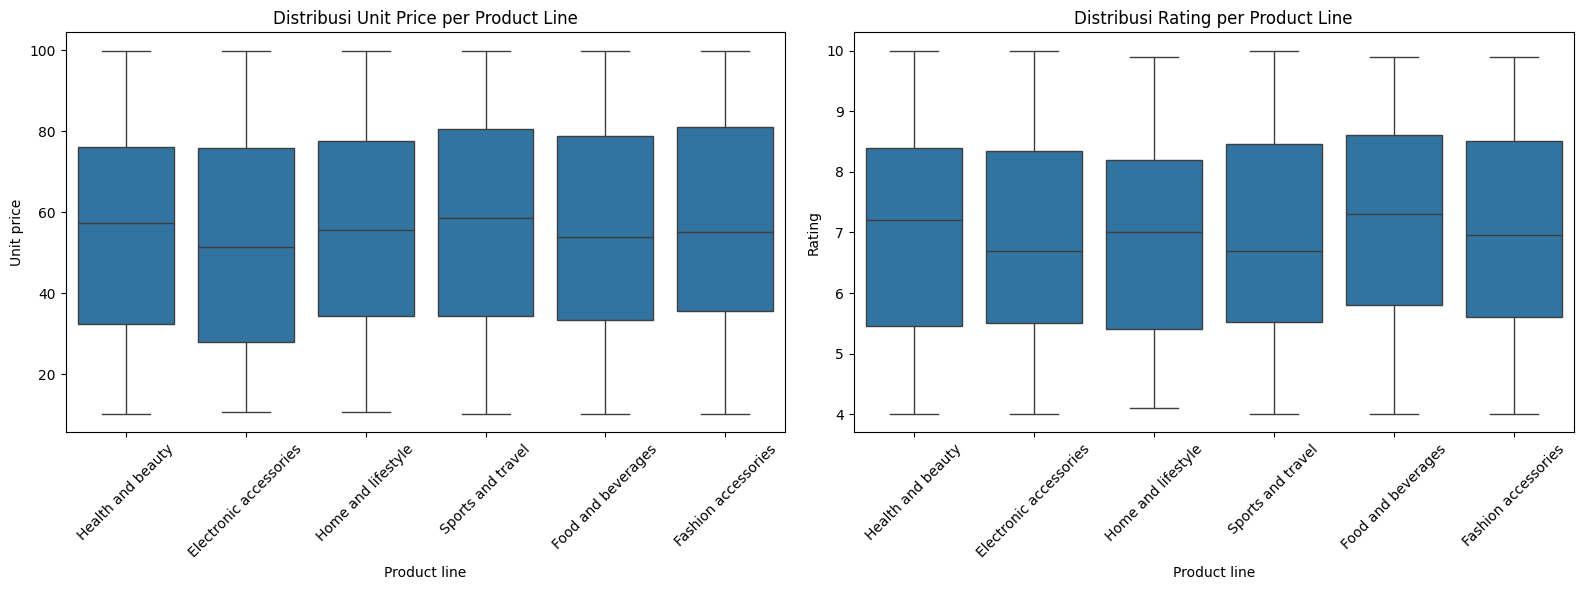

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Unit price per Product line
sns.boxplot(data=supermarket, x='Product line', y='Unit price', ax=axes[0])
axes[0].set_title('Distribusi Unit Price per Product Line')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot Rating per Product line
sns.boxplot(data=supermarket, x='Product line', y='Rating', ax=axes[1])
axes[1].set_title('Distribusi Rating per Product Line')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Bagian ini mencakup dua visualisasi:

1. **Distribusi Rating**: Menampilkan sebaran rating yang diberikan oleh pelanggan, untuk mengetahui tingkat kepuasan pelanggan terhadap produk atau layanan.
2. **Rata-rata Harga Produk per Product Line**: Menampilkan rata-rata harga unit produk berdasarkan kategori `Product line`, yang membantu dalam melihat kategori mana yang memiliki harga rata-rata tertinggi atau terendah.

Kedua visualisasi ini memberikan wawasan mengenai persepsi pelanggan dan nilai jual dari masing-masing kategori produk.

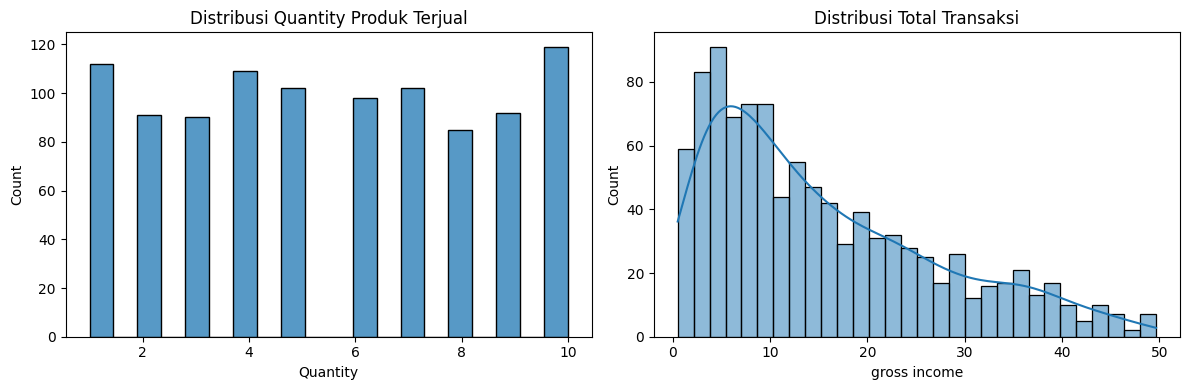

In [11]:
# Histogram Quantity dan Total transakasi (gross income)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(supermarket['Quantity'], bins=20, kde=False, ax=axes[0])
axes[0].set_title('Distribusi Quantity Produk Terjual')

sns.histplot(supermarket['gross income'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribusi Total Transaksi')

plt.tight_layout()
plt.show()

Visualisasi ini terdiri dari dua histogram:

1. **Quantity**: Menampilkan distribusi jumlah produk yang dibeli dalam satu transaksi.
   Ini berguna untuk mengetahui apakah pelanggan cenderung membeli dalam jumlah sedikit atau banyak.

2. **Gross Income**: Menunjukkan distribusi pendapatan kotor (`gross income`) per transaksi.
   Dengan menambahkan garis KDE, kita bisa memahami pola umum nilai transaksi di supermarket.

# Data Preparation

Dataset memiliki kolom `Date` dan `Time` yang masih berupa string. Pada tahap ini, kedua kolom tersebut dikonversi ke format datetime dan time Python agar lebih mudah diproses saat analisis waktu atau pembuatan fitur waktu tambahan. Kemudian di cek kembali tipe data menggunakan `supermaket.info()`

In [12]:
# Konversi tipe data 'Date' dan 'Time'
supermarket['Date'] = pd.to_datetime(supermarket['Date'])
supermarket['Time'] = pd.to_datetime(supermarket['Time'], format='%I:%M:%S %p').dt.time

print("Datasetail setelah konversi tipe data:")
print(supermarket.info())

Datasetail setelah konversi tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 

**Content-Based Filtering (CBF) preparation**

Kode dibawah tujuannya untuk membangun sistem rekomendasi berbasis konten, dibuat DataFrame berisi produk unik dan fitur-fitur yang akan digunakan, yaitu:
- `Product line`: kategori produk,
- `Rating`: penilaian pelanggan terhadap produk,
- `Unit price`: harga satuan produk.

Langkah ini penting untuk membangun representasi produk dalam sistem rekomendasi.

In [13]:
# Membuat DataFrame produk unik dengan fitur yang digunakan
df_product = supermarket[['Product line', 'Rating', 'Unit price']].drop_duplicates().reset_index(drop=True)

Kemudian menggabungkan fitur menjadi string untuk tahap TF-IDF, dan di implementasikan dengan kode dibawah ini.

In [14]:
# Mengabungkan fitur menjadi string untuk TF-IDF
df_product['features'] = df_product['Product line']  + ' ' + df_product['Rating'].astype(str) + ' ' + df_product['Unit price'].astype(str)

Kemudian dilakukan proses vektorisasi menggunakan TF-IDF (Term Frequency-Inverse Document Frequency). Vektor hasil TF-IDF ini kemudian digunakan untuk menghitung kemiripan antar produk, yang menjadi dasar rekomendasi.

In [15]:
# Menerapkan TfidfVectorizer
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df_product['features'])

**Collaborative Filtering (CF) Preparation**

Membuat kolom 'CustomerID' baru dalam DataFrame supermarket dengan menggabungkan 'Customer type' dan 'Gender'.

In [16]:
# Buat CustomerID dari gabungan Customer type dan Gender (karena data tidak ada user id asli)
supermarket['CustomerID'] = supermarket['Customer type'] + '_' + supermarket['Gender']

Kemudian dilakukan mapping antara ID pelanggan unik ('CustomerID') dan ID produk unik ('Product line') ke dalam bentuk indeks integer berurutan dengan kode di bawah ini.

In [17]:
# Mapping user dan product ke index integer
user_ids = supermarket['CustomerID'].unique()
product_ids = supermarket['Product line'].unique()

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
product_to_idx = {prod: idx for idx, prod in enumerate(product_ids)}

Kode dibawah ini untuk membuat sparse matrix user-product berdasarkan Quantity (bisa juga Total)

In [18]:
# Buat sparse matrix user-product berdasarkan Quantity (bisa juga Total)
rows = supermarket['CustomerID'].map(user_to_idx)
cols = supermarket['Product line'].map(product_to_idx)
data = supermarket['Quantity']

sparse_user_product = coo_matrix((data, (rows, cols)), shape=(len(user_ids), len(product_ids)))

# Modeling

### Content-Based Filtering (CBF)



Menunjukkan seberapa mirip setiap produk satu sama lain berdasarkan fitur-fitur yang digunakan

In [19]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

Menggunakan fungsi pencarian (atau fungsi rekomendasi) untuk menghasilkan rekomendasi produk serupa menggunakan skor kemiripan konten yang sudah dihitung sebelumnya.

In [20]:
# Fungsi pencarian untuk menghasilkan rekomendasi produk serupa menggunakan skor kemiripan konten yang sudah dihitung sebelumnya.
def recommend_product_based(product_index, top_n=5):
  similiar_scores = list(enumerate(cosine_sim[product_index]))
  similiar_scores = sorted(similiar_scores, key=lambda x: x[1], reverse=True)
  similiar_scores = similiar_scores[1:top_n+1]
  product_indices = [i[0] for i in similiar_scores]
  return df_product.iloc[product_indices]

In [21]:
# Tes Model
recommend_product_based(5)

,Product line,Rating,Unit price,features
55,Electronic accessories,8.2,85.98,Electronic accessories 8.2 85.98
291,Electronic accessories,6.0,27.85,Electronic accessories 6.0 27.85
172,Electronic accessories,6.3,20.85,Electronic accessories 6.3 20.85
680,Electronic accessories,6.5,39.48,Electronic accessories 6.5 39.48
877,Electronic accessories,6.1,39.75,Electronic accessories 6.1 39.75


Setelah model di tes, dapat dilihat output yang di hasilkan merupakan produk-produk yang paling mirip (serupa) dengan produk yang memiliki indeks ke-5 dalam DataFrame

### Collaborative Filtering (CF)

Mempersiapkan dan membangunan model Collaborative Filtering berbasis Item (Item-Based) menggunakan Cosine Similarity  untuk mempersiapkan data interaksi user-produk dan menghitung kemiripan antar produk menggunakan Cosine Similarity sebagai langkah awal dalam membangun model Collaborative Filtering berbasis Item.

In [22]:
# Collaborative Filtering dengan Cosine Similarity (Item-Based)
cf_pivot = supermarket.pivot_table(index='CustomerID', columns='Product line', values='Quantity', aggfunc='sum').fillna(0)

cf_similarity = cosine_similarity(cf_pivot.T)
cf_similarity_df = pd.DataFrame(cf_similarity, index=cf_pivot.columns, columns=cf_pivot.columns)

Pada kode dibawah ini kita menggunakan fungsi  untuk menghasilkan rekomendasi pada model Collaborative Filtering berbasis Item yang telah dibangun sebelumnya.

In [23]:
# fungsi untuk menghasilkan rekomendasi menggunakan model CF
def recommend_cf(product_line, top_n=5):
    if product_line not in cf_similarity_df.columns:
        return []
    similar_items = cf_similarity_df[product_line].sort_values(ascending=False)[1:top_n+1]
    return similar_items

In [24]:
# Tes model
recommend_cf("Electronic accessories", top_n=5)

,Electronic accessories
Product line,
Home and lifestyle,0.987936
Food and beverages,0.986583
Health and beauty,0.981283
Fashion accessories,0.980016
Sports and travel,0.972875


Kemudian model di tes pada kode diatas dan menghasilkan  daftar 5 produk yang paling mirip dengan "Electronic accessories" berdasarkan pola pembelian kolaboratif user, beserta skor kemiripan Cosine-nya.

# Evaluasi

### Content-Based Filtering


Evaluasi Content-Based Filtering. Metrik evaluasi yang digunakan untuk menilai performa model Content-Based Filtering (CBF) adalah Precision@K. Dengan membuat fungsi pada kode dibawah ini.

In [25]:
# Membuat fungsi untuk menghitung presisi model

def precision_at_k_cbf(product_index, k=5):
    target_product = df_product.iloc[product_index]
    target_category = target_product['Product line']

    recommended_items_df = recommend_product_based(product_index, top_n=k)

    # Hitung berapa banyak rekomendasi yang memiliki kategori yang sama
    relevant_recommended_count = recommended_items_df['Product line'].eq(target_category).sum()

    # Hitung Precision@K
    precision = relevant_recommended_count / k if k > 0 else 0

    return precision

Kemudian menghitung metrik precision dengan kode dibawah.

In [26]:
precisions = [precision_at_k_cbf(i, k=5) for i in df_product.index]
average_precision_cbf = np.mean(precisions)

print(f'\nPrecision Content-Based Filtering (based on category): {average_precision_cbf:.2f}')


Precision Content-Based Filtering (based on category): 0.84


Evaluasi model Content-Based Filtering (CBF) menggunakan Precision@5 menunjukkan hasil rata-rata sebesar 0.84, dengan definisi relevansi berdasarkan kesamaan kategori produk (Product line).

### Collaborative Filtering


Evaluasi Collaborative Filtering (CF) menggunakan beberapa metrik yang umum untuk mengevaluasi sistem rekomendasi dalam skenario Top-K recommendation dengan menggunakan metrik evaluasi precision dan recall.

Kemudian membuat fungsi untuk menghitung precision dan recall

In [27]:
def evaluate_cf_topk(k=5):
    total_precision = 0
    total_recall = 0
    total_items = 0

    for product in cf_similarity_df.index:
        recommended = recommend_cf(product, top_n=k).index.tolist()
        relevant_items = [p for p in cf_similarity_df.columns if p != product]

        if len(relevant_items) == 0:
          continue

        retrieved_relevant = [p for p in recommended if p in relevant_items]

        precision = len(retrieved_relevant) / k if k > 0 else 0
        recall = len(retrieved_relevant) / len(relevant_items)

        total_precision += precision
        total_recall += recall
        total_items += 1

    avg_precision = total_precision / total_items if total_items > 0 else 0
    avg_recall = total_recall / total_items if total_items > 0 else 0

    return avg_precision, avg_recall, k

Lalu menghitung precision dan recall

In [28]:
avg_precision, avg_recall, k_val = evaluate_cf_topk(k=5)

print(f"\nEvaluasi Collaborative Filtering (Top-{k_val})")
print(f"Precision@{k_val}: {avg_precision:.2f}")
print(f"Recall@{k_val}: {avg_recall:.2f}")


Evaluasi Collaborative Filtering (Top-5)
Precision@5: 1.00
Recall@5: 1.00


Evaluasi model Collaborative Filtering (CF) menggunakan metrik Average Precision@5 dan Average Recall@5 menunjukkan hasil sempurna, yaitu 1.00.